In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize
from uravu import plotting
from uravu.relationship import Relationship
import _fig_params

In [2]:
angle = np.linspace(20, 50, 60)
intensity = (0.6 * norm.pdf(angle, loc=25, scale=0.75)) + (
             0.15 * norm.pdf(angle, loc=27, scale=1)) + (
             0.25 * norm.pdf(angle, loc=43, scale=1.5)) + np.random.randn(60) * 0.003
uncertainty = np.ones(angle.size) * 0.015

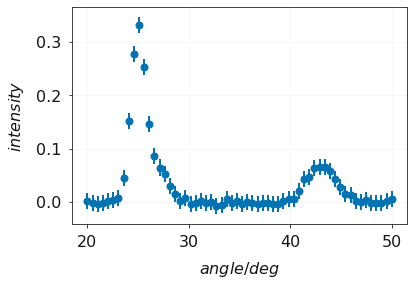

In [3]:
plt.errorbar(angle, intensity, uncertainty, marker='o', ls='')
plt.xlabel('$angle/deg$')
plt.ylabel('$intensity$')
plt.show()

In [4]:
def diff1(angle, a, b, c):
    return a * norm.pdf(angle, loc=b, scale=c)

bounds1 = ((0, 1), (20, 50), (0.1, 2))

In [5]:
def diff2(angle, a, b, c, d, e, f):
    return a * norm.pdf(angle, loc=b, scale=c) + d * norm.pdf(angle, loc=e, scale=f)

bounds2 = ((0, 1), (20, 50), (0.1, 2),
           (0, 1), (20, 50), (0.1, 2))

In [6]:
def diff3(angle, a, b, c, d, e, f, g, h, i):
    return a * norm.pdf(angle, loc=b, scale=c) + d * norm.pdf(
        angle, loc=e, scale=f) + g * norm.pdf(angle, loc=h, scale=i)

bounds3 = ((0, 1), (20, 50), (0.1, 2),
           (0, 1), (20, 50), (0.1, 2),
           (0, 1), (20, 50), (0.1, 2))

In [7]:
def diff4(angle, a, b, c, d, e, f, g, h, i, j, k, l):
    return a * norm.pdf(angle, loc=b, scale=c) + d * norm.pdf(
        angle, loc=e, scale=f) + g * norm.pdf(
        angle, loc=h, scale=i) + j * norm.pdf(
        angle, loc=k, scale=l)

bounds4 = ((0, 1), (20, 50), (0.1, 2),
           (0, 1), (20, 50), (0.1, 2),
           (0, 1), (20, 50), (0.1, 2),
           (0, 1), (20, 50), (0.1, 2))

In [8]:
r1 = Relationship(diff1, angle, intensity, ordinate_error=uncertainty, bounds=bounds1)
r2 = Relationship(diff2, angle, intensity, ordinate_error=uncertainty, bounds=bounds2)
r3 = Relationship(diff3, angle, intensity, ordinate_error=uncertainty, bounds=bounds3)
r4 = Relationship(diff4, angle, intensity, ordinate_error=uncertainty, bounds=bounds4)

In [9]:
r1.nested_sampling()

6556it [03:49, 28.56it/s, +500 | bound: 15 | nc: 1 | ncall: 27972 | eff(%): 25.225 | loglstar:   -inf < 122.564 <    inf | logz: 110.239 +/-  0.217 | dlogz:  0.001 >  0.509]


In [10]:
r2.nested_sampling()

9729it [08:43, 18.57it/s, +500 | bound: 59 | nc: 1 | ncall: 61577 | eff(%): 16.612 | loglstar:   -inf < 169.428 <    inf | logz: 150.597 +/-  0.278 | dlogz:  0.001 >  0.509]


In [ ]:
r3.nested_sampling()

6983it [25:43,  1.91s/it, bound: 180 | nc: 39 | ncall: 171521 | eff(%):  4.071 | loglstar:   -inf < 161.602 <    inf | logz: 146.311 +/-  0.238 | dlogz: 18.052 >  0.509]  

In [ ]:
r4.nested_sampling()